In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data.csv')
print(df.head())
print(df.shape)

  country           state               city  \
0   India  Andhra_Pradesh  Rajamahendravaram   
1   India  Andhra_Pradesh  Rajamahendravaram   
2   India  Andhra_Pradesh           Tirumala   
3   India  Andhra_Pradesh           Tirupati   
4   India  Andhra_Pradesh         Vijayawada   

                                          station          last_update  \
0  Anand Kala Kshetram, Rajamahendravaram - APPCB  12-04-2026 20:00:00   
1  Anand Kala Kshetram, Rajamahendravaram - APPCB  12-04-2026 20:00:00   
2                     Toll Gate, Tirumala - APPCB  12-04-2026 20:00:00   
3                 Vaikuntapuram, Tirupati - APPCB  12-04-2026 20:00:00   
4                   HB Colony, Vijayawada - APPCB  12-04-2026 20:00:00   

    latitude  longitude pollutant_id  pollutant_min  pollutant_max  \
0  16.987287  81.736318          NH3            2.0            3.0   
1  16.987287  81.736318          SO2            4.0           12.0   
2  13.670000  79.350000          NO2           41.0     

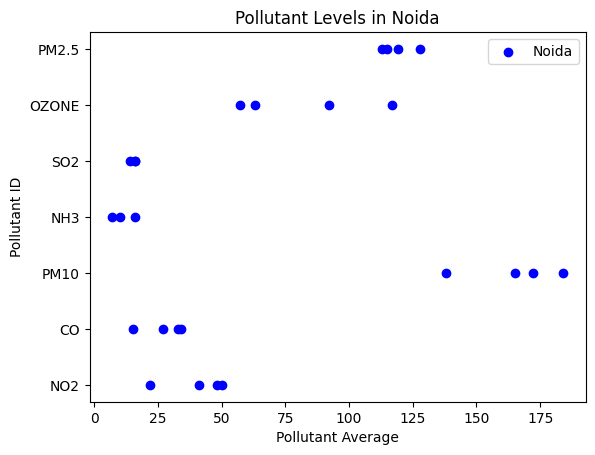

In [3]:
pm10 = df[df['pollutant_id'] == 'PM10']
# what if pm10 value pollutant_avg be more than 350 
pm10_high =  pm10[pm10['pollutant_avg']>150]
#print(pm10_high.sort_values('pollutant_avg', ascending=False))
#print(pm10_high)
#print(pm10.shape)
noida= df[df['city'] == 'Noida']
delhi= df[df['city'] == 'Delhi']
#print(noida.head())  
plt.scatter(noida['pollutant_avg'], noida['pollutant_id'], color='blue', label='Noida')
plt.xlabel('Pollutant Average')
plt.ylabel('Pollutant ID')
plt.title('Pollutant Levels in Noida')
plt.legend()
plt.show()


In [4]:
print(df['pollutant_id'].unique())

<StringArray>
['NH3', 'SO2', 'NO2', 'PM10', 'PM2.5', 'OZONE', 'CO']
Length: 7, dtype: str


- data is long format — one row per station per pollutant. reshape so each row is one station with all pollutants as columns. 
- what we'll do is here , that we are gonna take up all list of pollutants and make up a row 
- now we know that we have 7 different types of pollutants , so we are make columns new ones . 
- after making column we assign each row a unique station and pollutants values as present in them .

In [31]:
stations_pivoted = df.pivot_table(index='station',columns='pollutant_id',values='pollutant_avg', aggfunc='first')#.sort_values('PM10', ascending=False)

In [41]:
print(stations_pivoted.sort_values('PM10', ascending = False))

pollutant_id                                 CO   NH3   NO2  OZONE   PM10  \
station                                                                     
Gyaspur, Ahmedabad - IITM                  61.0  12.0  74.0   53.0  254.0   
DRM Office Danapur, Patna - BSPCB          38.0   8.0  38.0   15.0  246.0   
Knowledge Park - V, Greater Noida - UPPCB  17.0   9.0  74.0   75.0  245.0   
Loni, Ghaziabad - UPPCB                    12.0   4.0  40.0   77.0  233.0   
Sonia Vihar, Delhi - DPCC                  34.0   7.0  27.0   55.0  226.0   
...                                         ...   ...   ...    ...    ...   
Bapuji Nagar, Bengaluru - KSPCB            28.0   3.0  28.0    4.0    0.0   
Uchapatti, Madurai - TNPCB                 43.0   NaN   NaN    1.0    0.0   
Tondare-Taloja, Navi Mumbai - MPCB          5.0   3.0  34.0   25.0    0.0   
Urban, Chamarajanagar - KSPCB              24.0   2.0  21.0   29.0    0.0   
 Indira Nagar, Raebareli - NTPC Unchahar    7.0   9.0  18.0  135.0    0.0   

- derive binary target from PM2.5 and PM10 thresholds. check class balance — severe stations will be rare.
- here we have highest 254 pm10 and 183 pm2.5 so waht we can do to run our tests is taking threshold at 150 pm10 and 75 pm2.5

In [40]:
#so now we will fill 0 to na points
stations_pivoted['PM10'] = stations_pivoted['PM10'].fillna(0)
stations_pivoted['PM2.5'] = stations_pivoted['PM2.5'].fillna(0)



In [46]:
stations_pivoted['target'] = ((stations_pivoted['PM10'] > 150) | (stations_pivoted['PM2.5'] > 75)).astype(int)

print("=== CLASS BALANCE ===")
print(stations_pivoted['target'].value_counts())
print("\nPercentage of severe stations:", 
      round(stations_pivoted['target'].mean() * 100, 2), "%")
print("Total stations after pivot:", len(stations_pivoted))
print("\nNumber of severe stations:", stations_pivoted['target'].sum())

=== CLASS BALANCE ===
target
0    283
1    224
Name: count, dtype: int64

Percentage of severe stations: 44.18 %
Total stations after pivot: 507

Number of severe stations: 224


LOGISTIC REGRESSION FROM SCRATCH